# Predicting payment method via logistic regression

## **Project overview**
Which, if any, attitudinal and socio-economic attributes have the highest impact on a customer’s likelihood of purchasing with a credit agreement (instead of paying outright, in full), and how can a predictive model use these metrics to improve business profitability?

This project was conducted as part of my Data Science apprenticeship degree, forming part of my first year final assessment. It was accompanied with full documentation, in the form of a written project report.

## **1. Data preparation**

### Load the data
The data was downloaded from internal systems and imported into Google Colab. Required Python libraries were also imported.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive # Connect to Google Drive
drive.mount('/content/gdrive')

# Import customers data (downloaded from CRM system)
customers = pd.read_csv('/content/gdrive/MyDrive/Training + learning/Data Science apprenticeship degree/Python/cash_vs_ifc/Data/ifc_cash_rescore_customers.csv', na_values=['NAN'])
# Specify the required columns for the customers table (all others are removed)
customers = customers[['purchase_id', 'caci_ocean_gender', 'caci_lifestage', 'caci_internet_usage', 'caci_order_qty', 'caci_age_band', 'caci_household_income', 'caci_house_tenure', 'caci_has_credit_card', 'caci_household_size','caci_savings_value','caci_investments_value','caci_home_value','caci_dislikes_borrowing','caci_uses_buy_now_pay_later','caci_dislikes_debt']]

# Import purchase event data (downloaded from Retail system)
purchases = pd.read_csv('/content/gdrive/MyDrive/Training + learning/Data Science apprenticeship degree/Python/cash_vs_ifc/Data/ifc_cash_rescore_events.csv', na_values=['NAN'])
# Specify the required columns for the events table (all others are removed
purchases = purchases[['purchase_id','payment_type','rewrite', 'timestamp']]

# Merge the tables
combined = pd.merge(customers, purchases, how="inner", on="purchase_id")

print(combined.head())

Mounted at /content/gdrive
                  purchase_id caci_ocean_gender  \
0               ["T6ZQBFFCW"]            Female   
1  ["M6ZQBD7EC", "M6ZQBIX03"]            Female   
2  ["B4Y446628", "B4Y4ZK560"]            Female   
3               ["M6ZEBH49W"]              Male   
4               ["MAZLB5M4U"]            Female   

                  caci_lifestage caci_internet_usage  caci_order_qty  \
0  Family (18-54, with children)       Frequent user               8   
1  Family (18-54, with children)       Frequent user               0   
2                   Empty nester       Frequent user               2   
3  Family (18-54, with children)       Frequent user               3   
4  Family (18-54, with children)       Frequent user               2   

  caci_age_band caci_household_income caci_house_tenure caci_has_credit_card  \
0    Aged 50-54  Income 50,000-74,999    Owner-Occupied                    Y   
1    Aged 25-29  Income 10,000-19,999    Social Renting                  

In [2]:
# Rename the columns
combined.rename(columns={'caci_ocean_gender':'gender', 'caci_lifestage':'lifestage', 'caci_internet_usage':'internet_usage', 'caci_order_qty':'order_qty', 'caci_age_band':'age_band', 'caci_household_income':'household_income', 'caci_house_tenure':'house_tenure', 'caci_has_credit_card':'has_credit_card', 'caci_household_size':'household_size','caci_savings_value':'savings_value','caci_investments_value':'investments_value','caci_home_value':'home_value','caci_dislikes_borrowing':'dislikes_borrowing','caci_uses_buy_now_pay_later':'uses_buy_now_pay_later','caci_dislikes_debt':'dislikes_debt'}, inplace=True)

### Data cleaning

Before any analysis or modelling could begin, the data needed to be cleaned and transformed. Firstly, any "rewrite" rows were deleted. These are orders that have been significantly amended and issued a new purchase number, and should not be considered for this analysis.

In [3]:
# Delete all rows where 'rewrite' column is TRUE, then remove the rewrite column
combined = combined.drop(combined[combined['rewrite'] == 'TRUE'].index)
combined = combined.drop('rewrite', axis=1)

Next, the data was assessed for duplicates in the "purchase_id" column (this should be a unique identifier). None were found.

In [4]:
duplicate_purchase_id = combined.duplicated('purchase_id').sum() # Count the number of duplicate rows in 'purchase_id'
print(f"Number of duplicates in purchase_id: {duplicate_purchase_id}")

Number of duplicates in purchase_id: 0


The distinct values in all columns were then checked, to identify null/missing values, unexpected values or outliers.

In [5]:
print("gender")
for index, value in combined['gender'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['gender'].isna().sum())

print("\nlifestage")
for index, value in combined['lifestage'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['lifestage'].isna().sum())

print("\ninternet_usage")
for index, value in combined['internet_usage'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['internet_usage'].isna().sum())

print("\norder_qty")
for index, value in combined['order_qty'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['order_qty'].isna().sum())

print("\nage_band")
for index, value in combined['age_band'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['age_band'].isna().sum())

print("\nhousehold_income")
for index, value in combined['household_income'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['household_income'].isna().sum())

print("\nhouse_tenure")
for index, value in combined['house_tenure'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['house_tenure'].isna().sum())

print("\nhas_credit_card")
for index, value in combined['has_credit_card'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['has_credit_card'].isna().sum())

print("\nhousehold_size")
for index, value in combined['household_size'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['household_size'].isna().sum())

print("\nsavings_value")
for index, value in combined['savings_value'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['savings_value'].isna().sum())

print("\ninvestments_value")
for index, value in combined['investments_value'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['investments_value'].isna().sum())

print("\nhome_value")
for index, value in combined['home_value'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['home_value'].isna().sum())

print("\ndislikes_borrowing")
for index, value in combined['dislikes_borrowing'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['dislikes_borrowing'].isna().sum())

print("\nuses_buy_now_pay_later")
for index, value in combined['uses_buy_now_pay_later'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['uses_buy_now_pay_later'].isna().sum())

print("\ndislikes_debt")
for index, value in combined['dislikes_debt'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['dislikes_debt'].isna().sum())

print("\npayment_type")
for index, value in combined['payment_type'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['payment_type'].isna().sum())

gender
	 Female 461206
	 Male 347939
	 Unknown 1158
	 null 0

lifestage
	 Family (18-54, with children) 485625
	 Empty nester 145009
	 Retired 123240
	 Young (18-34, no children) 56429
	 null 0

internet_usage
	 Frequent user 538622
	 Moderate user 252521
	 Light user 4441
	 null 14719

order_qty
	 1 525972
	 2 130949
	 0 105252
	 3 34432
	 4 9382
	 5 2828
	 6 871
	 7 312
	 8 144
	 9 63
	 10 36
	 11 22
	 12 10
	 13 9
	 14 5
	 16 3
	 18 2
	 15 2
	 19 1
	 42 1
	 29 1
	 37 1
	 26 1
	 24 1
	 34 1
	 17 1
	 30 1
	 null 0

age_band
	 Aged 40-44 95761
	 Aged 35-39 90418
	 Aged 30-34 90101
	 Aged 55-59 89794
	 Aged 50-54 79547
	 Aged 25-29 77339
	 Aged 45-49 70562
	 Aged 60-64 67251
	 Aged 18-24 52714
	 Aged 65-69 37117
	 Aged 70-74 25854
	 Aged 75-79 16805
	 Aged 85+ 8534
	 Aged 80-84 8506
	 null 0

household_income
	 Income 50,000-74,999 216794
	 Income 40,000-49,999 119271
	 Income 20,000-29,999 104440
	 Income 10,000-19,999 93551
	 Income 30,000-39,999 93469
	 Income 75,000-99,999 86539
	 I

Observations:

*   gender has 1158 "unknown" values. These rows were removed.
*   internet_usage has 14719 missing values. These rows were removed.
*   Outliers identified in the order_qty column (likely due to unflagged rewrites - see earlier comment regarding rewrite orders). Rows with a value >5 were removed, as this was deemed an acceptable maximum given the nature of the business (high value, low frequency purchases, with a long repurchase cycle).






In [6]:
combined = combined.query("gender == 'Male' or gender == 'Female'") # Only keep valid 'gender' values
combined = combined.query("internet_usage == 'Frequent user' or internet_usage == 'Moderate user' or internet_usage == 'Light user'") # Only keep valid 'internet_usage' values

combined['order_qty'] = combined['order_qty'].astype(int) # Convert column to integer
combined = combined.drop(combined[combined.order_qty > 5].index) # Remove values greater than 5

# Recheck the values for these columns
print("gender")
for index, value in combined['gender'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['gender'].isna().sum())

print("\ninternet_usage")
for index, value in combined['internet_usage'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['internet_usage'].isna().sum())

print("\norder_qty")
for index, value in combined['order_qty'].value_counts().items():
    print("\t",index, value)
print("\t","null", combined['order_qty'].isna().sum())

gender
	 Female 451376
	 Male 341632
	 null 0

internet_usage
	 Frequent user 537061
	 Moderate user 251512
	 Light user 4435
	 null 0

order_qty
	 1 516529
	 2 127351
	 0 104062
	 3 33302
	 4 9052
	 5 2712
	 null 0


In [7]:
combined['timestamp'] = pd.to_datetime(combined['timestamp'])

The datatypes of each column were assessed and found to be correct:

In [8]:
print(combined.dtypes) # Check the data types are correct

purchase_id                       object
gender                            object
lifestage                         object
internet_usage                    object
order_qty                          int64
age_band                          object
household_income                  object
house_tenure                      object
has_credit_card                   object
household_size                    object
savings_value                     object
investments_value                 object
home_value                        object
dislikes_borrowing                object
uses_buy_now_pay_later            object
dislikes_debt                     object
payment_type                      object
timestamp                 datetime64[ns]
dtype: object


The data contained no personally identifiable information (PII). Whilst some of the columns may be deemed sensitive data, the identity of the customers they correspond to is masked through use of their anonymous purchase_id (rather than, for example, their name or email address). Consequently, none of the data needed to be masked or removed. Therefore, the cleaning of the data was complete.

## **2. Initial Exploratory Data Analysis (EDA)**


In [9]:
combined.describe()

,order_qty,timestamp
count,793008.000000,793008
mean,1.161281,2023-04-19 18:32:55.748105216
min,0.000000,2022-05-16 01:24:42
25%,1.000000,2022-11-04 16:09:41
50%,1.000000,2023-04-06 17:45:28.500000
75%,1.000000,2023-10-08 14:30:28.500000
max,5.000000,2024-05-13 00:20:15
std,0.768918,NaN


#### Relationship between customer demographics and IFC usage
The breakdown of payment methods across various demographic metrics was assessed with stacked bar charts.

In [10]:
grouped_data_a = combined.groupby(['age_band', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Simplify the income labels
age_mapping = {
       'Aged 18-24':'18-24',
       'Aged 25-29':'25-29',
       'Aged 30-34':'30-34',
       'Aged 35-39':'35-39',
       'Aged 40-44':'40-44',
       'Aged 45-49':'45-49',
       'Aged 50-54':'50-54',
       'Aged 55-59':'55-59',
       'Aged 60-64':'60-64',
       'Aged 65-70':'65-70',
       'Aged 70-74':'70-74',
       'Aged 75-79':'75-79',
       'Aged 80-84':'80-84',
       'Aged 85+':'85+'
}

# Map the income labels to the new labels
grouped_data_a['age_band'] = grouped_data_a['age_band'].map(age_mapping)

# Plot the new dataframe
fig_a = px.histogram(grouped_data_a, x="age_band", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of count (normalized as percent)": "Number of purchases", "age_band": "Age", "payment_type" : "Payment method"})
fig_a.update_layout(height=500,
                  width=1000,
                  title={'text': "Number of cash and IFC payments by age",'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                  yaxis_title="Number of purchases (normalised as percent)",
                  xaxis_title="Age range",
                  legend_title="Payment method",
                  plot_bgcolor='white',
                  paper_bgcolor='white')
fig_a.show()

In [11]:
grouped_data_b = combined.groupby(['household_income', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Simplify the income labels
income_mapping = {
    'Income 0-9,999': '0-9,999',
    'Income 10,000-19,999': '10,000-19,999',
    'Income 20,000-29,999': '20,000-29,999',
    'Income 30,000-39,999': '30,000-39,999',
    'Income 40,000-49,999': '40,000-49,999',
    'Income 50,000-74,999': '50,000-74,999',
    'Income 75,000-99,999': '75,000-99,999',
    'Income 100,000+': '100,000+'
}

# Map the income labels to the new labels
grouped_data_b['household_income'] = grouped_data_b['household_income'].map(income_mapping)

# Plot the new dataframe
fig_b = px.histogram(grouped_data_b, x="household_income", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "household_income": "Household income", "payment_type": "Payment method"})
fig_b.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by household income", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Household income (£)",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_b.show()

In [12]:
grouped_data_c = combined.groupby(['house_tenure', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_c = px.histogram(grouped_data_c, x="house_tenure", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "house_tenure": "House tenure", "payment_type": "Payment method"})
fig_c.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by house tenure", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="House tenure",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_c.show()

In [13]:
grouped_data_d = combined.groupby(['lifestage', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_d = px.histogram(grouped_data_d, x="lifestage", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "lifestage": "Lifestage", "payment_type": "Payment method"},
             category_orders={'lifestage':['Young (18-34, no children)', 'Family (18-54, with children)', 'Empty nester', 'Retired']})
fig_d.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by lifestage", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Lifestage",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_d.show()

In [14]:
grouped_data_e = combined.groupby(['internet_usage', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_e = px.histogram(grouped_data_e, x="internet_usage", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "internet_usage": "Internet usage", "payment_type": "Payment method"},
             category_orders={'internet_usage':['Light user', 'Moderate user', 'Frequent user']})
fig_e.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by internet usage", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Internet usage",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_e.show()

In [15]:
grouped_data_f = combined.groupby(['household_size', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_f = px.histogram(grouped_data_f, x="household_size", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "household_size": "household size", "payment_type": "Payment method"})
fig_f.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by household size", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Household size",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_f.show()

In [16]:
grouped_data_g = combined.groupby(['home_value', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_g = px.histogram(grouped_data_g, x="home_value", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "home_value": "Home value", "payment_type": "Payment method"},
             category_orders={'home_value':['0 to 100k', '100k to 150k', '150k to 250k', '250k to 500k', '500k to 750k', '750k to 1m', '1m+']}
)
fig_g.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by home value", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Home value (£)",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_g.show()

In [17]:
grouped_data_h = combined.groupby(['savings_value', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_h = px.histogram(grouped_data_h, x="savings_value", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "savings_value": "Savings value", "payment_type": "Payment method"},
             category_orders={'savings_value':['0 to 100k', '100k to 150k', '150k to 250k', '250k to 500k', '500k to 750k', '750k to 1m', '1m+']}
)
fig_h.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by savings value", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Savings value (£)",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_h.show()

In [18]:
grouped_data_i = combined.groupby(['investments_value', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_i = px.histogram(grouped_data_i, x="investments_value", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of Number of purchases (normalized as percent)": "Number of purchases", "investments_value": "Investments value", "payment_type": "Payment method"},
             category_orders={'investments_value':['No investments', '1 - 500', '500 - 2,500', '2,500 - 10,000', '10,000 - 25,000', '25,000 - 100,000', '100,000+']}
)
fig_i.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by investments value", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Investments value (£)",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_i.show()

Observations:
*   59% of orders were placed with finance.
*   Very low-income households (<£9,999) are most likely to use IFC, and very high-income (>£100,000) are least likely. However, the overall difference across income brackets is small.
*   IFC usage is highest between ages 25-39. This is an often-expensive age, when many people have children, buy houses, or get married. This is further shown by the observation that IFC usage peaks at the “Family” lifestage.
*   IFC usage is very low over age 80.
*   Owner-occupied households are more likely to pay with cash than renters.
*   Customers with higher home values or higher savings values are less likely to use IFC (as, presumably, they have greater disposable income avaiable to them to pay with cash). However, investment value displays little correlation with payment method.
*   94% of light internet users paid by cash, versus 33% of moderate users and 37% of frequent users.

#### IFC usage over time
Next, the impact of time of year on IFC usage was investigated.

In [19]:
combined['month'] = combined['timestamp'].dt.to_period('M').dt.strftime('%m') # Extract the month from the timestamp column and convert it to string
grouped_data_j = combined.groupby(['month', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Simplify the month labels
month_mapping = {
    '01': 'Jan',
    '02': 'Feb',
    '03': 'Mar',
    '04': 'Apr',
    '05': 'May',
    '06': 'Jun',
    '07': 'Jul',
    '08': 'Aug',
    '09': 'Sep',
    '10': 'Oct',
    '11': 'Nov',
    '12': 'Dec',
}

# Map the month labels to the new labels
grouped_data_j['month'] = grouped_data_j['month'].map(month_mapping)

# Plot the new dataframe
fig_j = px.histogram(grouped_data_j, x="month", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of count (normalized as percent)": "Number of purchases", "month": "Month", "payment_type": "Payment method"})
fig_j.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by month", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Month",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_j.show()

In [20]:
combined['day'] = combined['timestamp'].dt.to_period('D').dt.strftime('%d') # Extract the day from the timestamp column and convert it to string
grouped_data_k = combined.groupby(['day', 'payment_type']).size().reset_index(name='count') # Create a new dataframe

# Plot the new dataframe
fig_k = px.histogram(grouped_data_k, x="day", y="count", color="payment_type",
             pattern_shape="payment_type",
             barnorm='percent',
             color_discrete_map={"finance": 'rgb(199,3,127)', "cash": 'rgb(77,29,128)'},
             labels={"sum of count (normalized as percent)": "Number of purchases", "day": "Day", "payment_type": "Payment method"})
fig_k.update_layout(height=500,
                    width=1000,
                    title={'text': "Number of cash and IFC payments by day", 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'},
                    yaxis_title="Number of purchases (normalised as percent)",
                    xaxis_title="Day",
                    legend_title="Payment method",
                    plot_bgcolor='white',
                    paper_bgcolor='white')
fig_k.show()

### Categorical variable proportions

In [21]:
# Calculate the count of each home value category
home_value_counts = combined['house_tenure'].value_counts()

# Create a donut chart
fig = px.pie(home_value_counts, values=home_value_counts.values, names=home_value_counts.index, hole=0.5, color_discrete_sequence=px.colors.sequential.Agsunset)
fig.update_traces(textposition='outside', textinfo='percent+label')

# Add a title to the chart
fig.update_layout(title_text='Proportion of house tenure')

# Update the layout
fig.update_layout(
    width=500,
    height=400,
    title={
        'text': "Proportion of house tenure",
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    plot_bgcolor='white',
    paper_bgcolor='white',
)

fig.update(layout_showlegend=False)

fig.update_traces(hoverinfo='label+percent', textfont_size=16,
                  marker=dict(colors=px.colors.sequential.Agsunset, line=dict(color='#000000', width=1)))

# Display the chart
fig.show()


*(Additional EDA was run after the following transformation steps)*

## **3. Data transformation**

With the exception of 'order_qty', all columns were categorical object datatypes. In order to run logisitc regression using these categorical variables, they needed to be transformed into numeric values. The three transformation methods applied are summarised below.

### 3.1. Mapping to specified numeric values
This applied to the categorical values that show some sort of logical scale or sequence, namely: 'internet_usage', 'age_band', 'household_income', 'household_size', 'savings_value', 'investments_value' and 'home_value'. The values were replaced with numbers, in order of their natural sequence.

In [22]:
replace_internet = {'None':'0', 'Light user':'2', 'Moderate user':'3', 'Frequent user':'4'}
combined['internet_usage'] = combined['internet_usage'].map(replace_internet)

replace_age_band = {'Aged 18-24':'1', 'Aged 25-29':'2', 'Aged 30-34':'3', 'Aged 35-39':'4', 'Aged 40-44':'5', 'Aged 45-49':'6', 'Aged 50-54':'7', 'Aged 55-59':'8', 'Aged 60-64':'9', 'Aged 65-70':'10', 'Aged 70-74':'11', 'Aged 75-79':'12', 'Aged 80-84':'13', 'Aged 85+':'14'}
combined['age_band'] = combined['age_band'].map(replace_age_band)

replace_income = {'Income 0-9,999':'1', 'Income 10,000-19,999':'2', 'Income 20,000-29,999':'3', 'Income 30,000-39,999':'4', 'Income 40,000-49,999':'5', 'Income 50,000-74,999':'6', 'Income 75,000-99,999':'7', 'Income 100,000+':'8'}
combined['household_income'] = combined['household_income'].map(replace_income)

replace_household_size = {'1 person':'1', '2 persons':'2', '3-4 persons':'3', '5+ persons':'4'}
combined['household_size'] = combined['household_size'].map(replace_household_size)

replace_savings = {'No savings':'1', '1 - 500':'2', '500 - 2,500':'3', '2,500 - 10,000':'4', '10,000 - 25,000':'5', '25,000 - 100,000':'6', '100,000+':'7'}
combined['savings_value'] = combined['savings_value'].map(replace_savings)

replace_investments = {'No investments':'1', '1 - 500':'2', '500 - 2,500':'3', '2,500 - 10,000':'4', '10,000 - 25,000':'5', '25,000 - 100,000':'6', '100,000+':'7'}
combined['investments_value'] = combined['investments_value'].map(replace_investments)

replace_home_value = {'0 to 100k':'1', '100k to 150k':'2', '150k to 250k':'3', '250k to 500k':'4', '500k to 750k':'5', '750k to 1m':'6', '1m+':'7'}
combined['home_value'] = combined['home_value'].map(replace_home_value)

### 3.2. Replaced with binary values
Columns with only two options were replaced with binary values, namely: 'gender', 'payment_type', 'has_credit_card', 'dislikes_borrowing', 'uses_buy_now_pay_later' and 'dislikes_debt'.

In [23]:
replace_gender = {'Male':'1', 'Female':'0'}
combined['gender'] = combined['gender'].map(replace_gender)

replace_payment_type = {'finance':'1', 'cash':'0'}
combined['payment_type'] = combined['payment_type'].map(replace_payment_type)

replace_has_credit_card = {'Y':'1', 'N':'0'}
combined['has_credit_card'] = combined['has_credit_card'].map(replace_has_credit_card)

replace_dislikes_borrowing = {'Y':'1', 'N':'0'}
combined['dislikes_borrowing'] = combined['dislikes_borrowing'].map(replace_dislikes_borrowing)

replace_uses_buy_now_pay_later = {'Y':'1', 'N':'0'}
combined['uses_buy_now_pay_later'] = combined['uses_buy_now_pay_later'].map(replace_uses_buy_now_pay_later)

replace_dislikes_debt = {'Y':'1', 'N':'0'}
combined['dislikes_debt'] = combined['dislikes_debt'].map(replace_dislikes_debt)

### 3.3. One hot encoding
One hot encoding is the process of pivoting single columns with multiple values into a series of new columns. Each column represents one of the distinct values in the original column, and the rows have binary 1/0 values. This applies to 'lifestage' and 'house_tenure', as these columns contain more than 2 values, which do not follow a natural order.

In [24]:
# Pivot the lifestage column into its own table, so it is in the required format (each value as a separate column). Replace non-matching values with 0.
lifestage = combined.pivot(index='purchase_id', columns='lifestage', values='lifestage').reset_index().fillna('0')
# Replace all non-0 values with 1
lifestage["Young (18-34, no children)"]=lifestage["Young (18-34, no children)"].replace('Young (18-34, no children)', '1')
lifestage["Family (18-54, with children)"]=lifestage["Family (18-54, with children)"].replace('Family (18-54, with children)', '1')
lifestage["Retired"]=lifestage["Retired"].replace('Retired', '1')
lifestage["Empty nester"]=lifestage["Empty nester"].replace('Empty nester', '1')
# Change data types to integer
lifestage['Young (18-34, no children)'] = lifestage['Young (18-34, no children)'].astype(int)
lifestage['Family (18-54, with children)'] = lifestage['Family (18-54, with children)'].astype(int)
lifestage['Retired'] = lifestage['Retired'].astype(int)
lifestage['Empty nester'] = lifestage['Empty nester'].astype(int)
# Combine the pivoted lifestage table with the master table, and drop the original lifestage column
combined = pd.merge(combined, lifestage, how="inner", on="purchase_id")
combined = combined.drop('lifestage', axis=1)

# Pivot the house_tenure column into its own table, so it is in the required format (each value as a separate column). Replace non-matching values with 0.
house_tenure = combined.pivot(index='purchase_id', columns='house_tenure', values='house_tenure').reset_index().fillna('0')
# Replace all non-0 values with 1
house_tenure["Owner-Occupied"]=house_tenure["Owner-Occupied"].replace('Owner-Occupied', '1')
house_tenure["Social Renting"]=house_tenure["Social Renting"].replace('Social Renting', '1')
house_tenure["Private Renting"]=house_tenure["Private Renting"].replace('Private Renting', '1')
# Change data types to integer
house_tenure['Owner-Occupied'] = house_tenure['Owner-Occupied'].astype(int)
house_tenure['Social Renting'] = house_tenure['Social Renting'].astype(int)
house_tenure['Private Renting'] = house_tenure['Private Renting'].astype(int)
# Combine the pivoted house_tenure table with the master table, and drop the original house_tenure column
combined = pd.merge(combined, house_tenure, how="inner", on="purchase_id")
combined = combined.drop('house_tenure', axis=1)

### Final data transformation and validation

In [25]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793008 entries, 0 to 793007
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   purchase_id                    793008 non-null  object        
 1   gender                         793008 non-null  object        
 2   internet_usage                 793008 non-null  object        
 3   order_qty                      793008 non-null  int64         
 4   age_band                       758739 non-null  object        
 5   household_income               793008 non-null  object        
 6   has_credit_card                793008 non-null  object        
 7   household_size                 793008 non-null  object        
 8   savings_value                  793008 non-null  object        
 9   investments_value              793008 non-null  object        
 10  home_value                     793008 non-null  object        
 11  

Observations and actions

*   The 'purchase_id' column is still present, but no longer required. It was dropped.
*   The 'age_band' contains a small number of null values. These rows were dropped.
*   Many columns are still object datatypes. They were updated to integer.



In [26]:
combined = combined.drop('purchase_id', axis=1) # Drop 'purchase_id' column as it is no longer required

combined = combined.dropna(subset=['age_band']) # Remove null values in age_band column

# Convert all columns to integers
cols = combined.columns[combined.dtypes.eq('object')]
combined[cols] = combined[cols].apply(pd.to_numeric, errors='coerce')

## **4. Further Exploratory Data Analysis**

With the data now transformed into more usable formats, it was possible to run further exploratory data analysis to uncover additional insights.

### Variable correlations with payment type

The correlation between each variable and the payment method was visualised in a heatmap.

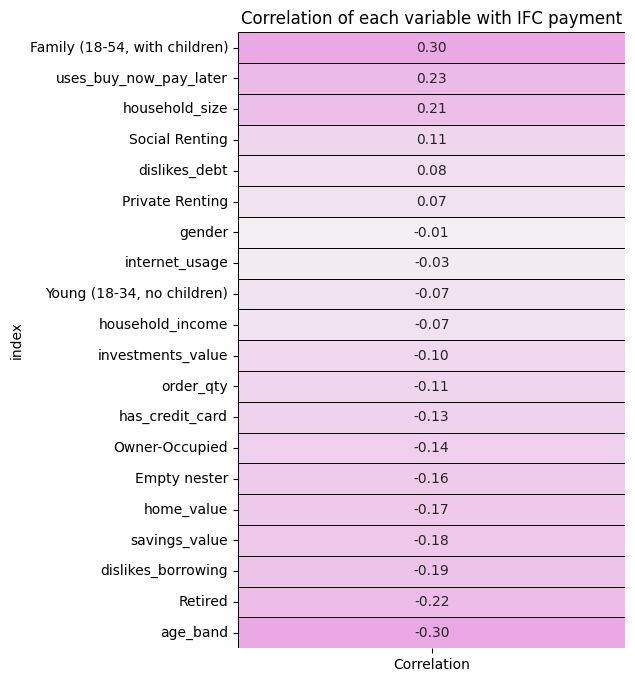

In [44]:
# set the target variable
target_column = 'payment_type'

# Calculate the correlation matrix
corr_columns_to_drop = ['timestamp', 'day', 'month']
correlation_matrix_source = combined.drop(columns=corr_columns_to_drop)
correlation_matrix = correlation_matrix_source.corr()

# Get the correlations with the target column
target_correlations = correlation_matrix[target_column]

# Drop the correlation of the target column with itself
target_correlations = target_correlations.drop(labels=[target_column])

# Convert the series to a dataFrame for better visualization
target_correlations_df = target_correlations.reset_index().rename(columns={target_column: 'Correlation'})

# Set the index to the predictor variables
target_correlations_df = target_correlations_df.set_index('index')
target_correlations_df = target_correlations_df.sort_values(by=['Correlation'], ascending=False)

# Plot the heatmap
plt.figure(figsize=(5, 8))
cmap = sns.diverging_palette(315,315, s=100, as_cmap=True)
sns.heatmap(target_correlations_df, annot=True, cmap=cmap, vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, linecolor='black', cbar=False)
plt.title("Correlation of each variable with IFC payment")
plt.show()

The chart above shows generally low correlation across all variables. However, these variables may compound in the final model to provide accurate results.

### Assess multicollinearity
The correlation of each variable with every other variable was calculated and plotted in a heatmap. This provides a quick way to visualise any potential multicollinearity between the variables, which could have implications on the success of the model.

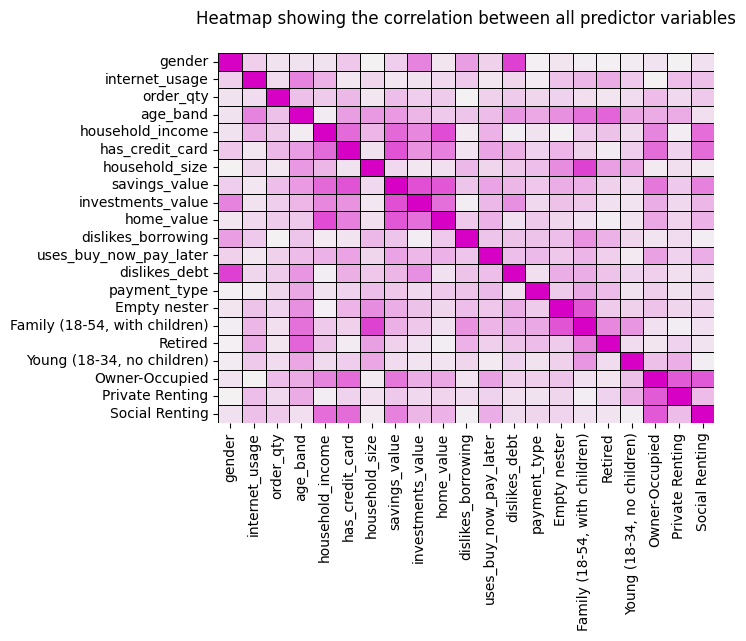

In [45]:
# check for multicollinearity with a heatmap
sns.heatmap(correlation_matrix_source.corr(), annot=False, cmap=cmap, vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, linecolor='black', cbar=False)
plt.title("Heatmap showing the correlation between all predictor variables\n")
plt.show()

In [29]:
print("Correlation between dislikes_debt and gender =",combined['dislikes_debt'].corr(combined['gender']))
print("Correlation between Family (18-54, with children) and household_size =",combined['Family (18-54, with children)'].corr(combined['household_size']))
print("Correlation between home_value and savings_value=",combined['savings_value'].corr(combined['home_value']))

Correlation between dislikes_debt and gender = -0.7341662331828251
Correlation between Family (18-54, with children) and household_size = 0.7197013242735824
Correlation between home_value and savings_value= 0.6339761011110122


Some variables exhibited a high correlation, notably:
*   dislikes_debt/gender = 0.73
*   Family (18-54, with children)/household_size = 0.72
*   home_value/savings_value = 0.63
This potential multicollinearity will be explored in future iterations of this analysis.

All other variables displayed a low correlation, making them appropriate to use in the regression modelling.

## **5. Building the logistic regression model**

With the data imported, cleaned and transformed, the logistic regression model was then built. Two models were build, each trained with a different combination of predicter variables:
*   Model 1: All variables (to assess the potential impacts of compounding)
*   Model 2: Only the variables with an absolute correlation coefficient to IFC of >0.1.

### Model 1 (all variables)

In [30]:
# Split dataset into predictor and target variables
predictor_variables_1 = ['gender', 'internet_usage', 'order_qty', 'age_band', 'household_income', 'has_credit_card', 'household_size', 'savings_value', 'investments_value', 'home_value', 'dislikes_borrowing', 'uses_buy_now_pay_later', 'dislikes_debt', 'Empty nester', 'Family (18-54, with children)', 'Retired', 'Young (18-34, no children)', 'Owner-Occupied', 'Private Renting', 'Social Renting']
X_1 = combined[predictor_variables_1] # Predictors
y_1 = combined.payment_type # Target variable

# Split the data into training and testing data sets
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.25, random_state=16)

# Run the logistic regression model
logreg_1 = LogisticRegression(random_state=16, max_iter=500) # increase the 'max_iter' to better optimise the model
logreg_1.fit(X_train_1, y_train_1)
y_pred_1 = logreg_1.predict(X_test_1)

#### ROC curve 1

An ROC curve was plotted to assess the model's performance versus the random classifier.

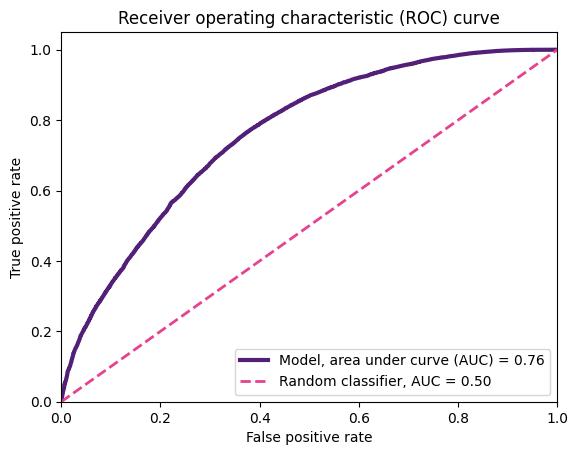

In [31]:
y_pred_probability_1 = logreg_1.predict_proba(X_test_1)[::,1]
fpr_1, tpr_1, _ = metrics.roc_curve(y_test_1, y_pred_probability_1)
auc_1 = metrics.roc_auc_score(y_test_1, y_pred_probability_1)
plt.plot(fpr_1,tpr_1,color='#522078',label='Model, area under curve (AUC) = %0.2f' % auc_1, linewidth=3)
plt.plot([0, 1], [0, 1], 'r--',color='#e64290', linewidth=2, label='Random classifier, AUC = 0.50') # plots the random classifier line
plt.xlim([0.0, 1.0]) # adjusts x-axis scale
plt.ylim([0.0, 1.05]) # adjusts y-axis scale
plt.title('Receiver operating characteristic (ROC) curve', y=1)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.legend()
plt.show()

#### Threshold optimisation 1

The Python package does not automatically optimise the logistic regression to determine an optimal threshold. Therefore, a Precision/Recall graph was plotted to establish the optimal threshold.

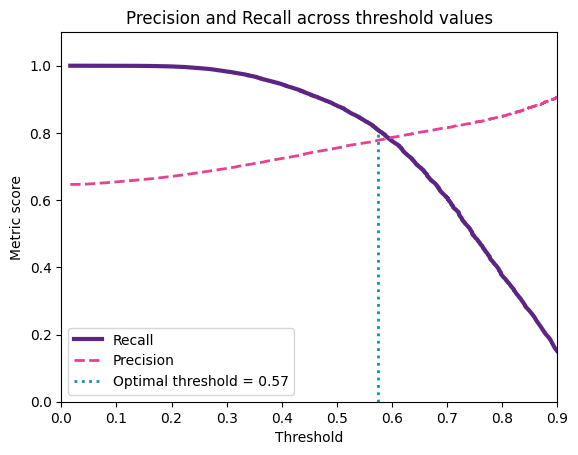

In [32]:
# Predict test_y values and probabilities based on fitted logistic regression model
pred_y_1=logreg_1.predict(X_test_1)
probs_y_1=logreg_1.predict_proba(X_test_1)

# probs_y is a 2-D array of probability of being labeled as 0

precision_1, recall_1, thresholds_1 = precision_recall_curve(y_test_1, probs_y_1[:,1])
#retrieve probability of being 1(in second column of probs_y)
pr_auc_1 = metrics.auc(recall_1, precision_1)

plt.title("Precision and Recall across threshold values")
plt.plot(thresholds_1, recall_1[: -1], "r-", label="Recall", color='#5c2483', linewidth=3)
plt.plot(thresholds_1, precision_1[: -1], "b--", label="Precision", color='#e64290', linewidth=2)
plt.ylabel("Metric score")
plt.xlabel("Threshold")
plt.legend(loc="lower left")
optimal_idx_1 = np.argmax(tpr_1 - fpr_1)
optimal_threshold_1 = thresholds_1[optimal_idx_1]
plt.plot([optimal_threshold_1, optimal_threshold_1], [0, 0.8], "k:", color='#089899', label='Optimal threshold = %0.2f' % optimal_threshold_1, linewidth=2)
plt.ylim([0,1.1])
plt.xlim([0,0.9])
plt.legend()
plt.show()

0.57 was accepted as the optimal threshold.

#### Confusion Matrix 1

Finally, a confusion matrix was plotted and associated accuracy metrics were calculated for this model.

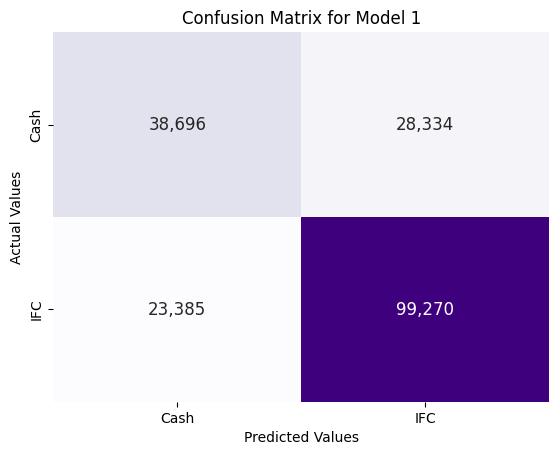

In [33]:
# Set the threshold for the confusion matrix to the optimal threshold (without this step, ot would be set to a default of 0.5)
y_pred_1 = (logreg_1.predict_proba(X_test_1)[:, 1] > optimal_threshold_1).astype('float')

# Generate the confusion matrix
cm_1 = confusion_matrix(y_test_1, y_pred_1)

# Define custom colors and layout
ax_1 = plt.subplot()
sns.heatmap(cm_1, annot=True, annot_kws={"size": 12}, ax=ax_1, cmap="Purples", cbar=False, fmt=',.0f')

# Set labels and title
ax_1.set_xlabel("Predicted Values")
ax_1.set_ylabel("Actual Values")
ax_1.set_title("Confusion Matrix for Model 1")

# Set tick labels for x and y axes
ax_1.xaxis.set_ticklabels(["Cash", "IFC"])
ax_1.yaxis.set_ticklabels(["Cash", "IFC"])

# Show the plot
plt.show()

In [34]:
Accuracy_1 = metrics.accuracy_score(y_test_1, y_pred_1)
Precision_1 = metrics.precision_score(y_test_1, y_pred_1)
Recall_1 = metrics.recall_score(y_test_1, y_pred_1)
Specificity_1 = metrics.recall_score(y_test_1, y_pred_1, pos_label=0)
F1_score_1 = metrics.f1_score(y_test_1, y_pred_1)

print("Accuracy:", Accuracy_1)
print("Precision:", Precision_1)
print("Sensitivity/Recall:", Recall_1)
print("Specificity:", Specificity_1)
print("F1 score:", F1_score_1)

Accuracy: 0.7273426997390411
Precision: 0.777953669163976
Sensitivity/Recall: 0.8093432799315152
Specificity: 0.5772937490675817
F1 score: 0.7933381017266111


### Model 2 (selected variables)

The previously outlined steps that were used to develop model 1 were repeated. However, for this model (model 2), the predictor variables used to train the model were limited only to those with an absolute correlation value greater than 0.1 with a payment method of IFC.

In [35]:
# Split dataset into predictor and target variables. Predictor variables limited only to those with an absolute correlation with IFC of >0.1.
predictor_variables_2 = ['order_qty', 'age_band', 'has_credit_card', 'household_size', 'savings_value', 'investments_value', 'home_value', 'dislikes_borrowing', 'uses_buy_now_pay_later', 'Empty nester', 'Family (18-54, with children)', 'Retired', 'Owner-Occupied', 'Social Renting']
X_2 = combined[predictor_variables_2] # Predictors
y_2 = combined.payment_type # Target variable

# Split the data into training and testing data sets
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.25, random_state=16)

# Run the logistic regression model
logreg_2 = LogisticRegression(random_state=16, max_iter=500) # increase the 'max_iter' to better optimise the model
logreg_2.fit(X_train_2, y_train_2)
y_pred_2 = logreg_2.predict(X_test_2)

#### ROC Curve 2

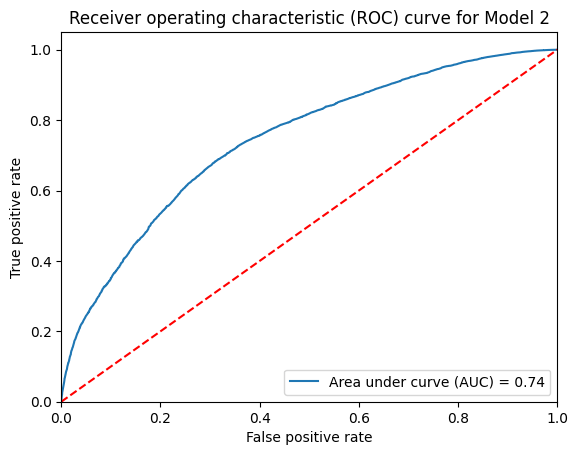

In [36]:
y_pred_probability_2 = logreg_2.predict_proba(X_test_2)[::,1]
fpr_2, tpr_2, _ = metrics.roc_curve(y_test_2, y_pred_probability_2)
auc_2 = metrics.roc_auc_score(y_test_2, y_pred_probability_2)
plt.plot(fpr_2,tpr_2,label='Area under curve (AUC) = %0.2f' % auc_2)
plt.legend(loc=4)
plt.plot([0, 1], [0, 1],'r--') # plots the random classifier line
plt.xlim([0.0, 1.0]) # adjusts x-axis scale
plt.ylim([0.0, 1.05]) # adjusts y-axis scale
plt.title('Receiver operating characteristic (ROC) curve for Model 2', y=1)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

#### Threshold optimisation 2

(0.0, 0.9)

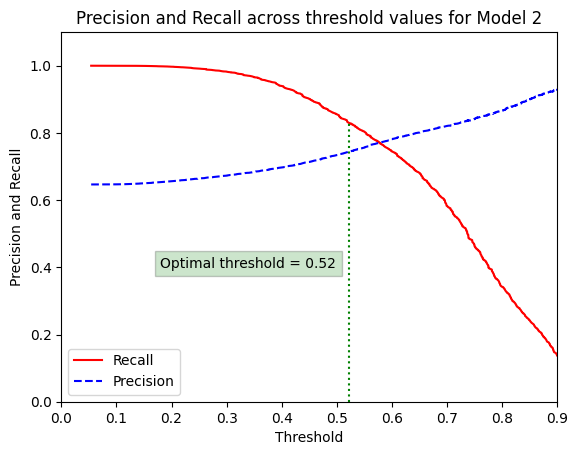

In [37]:
# Predict test_y values and probabilities based on fitted logistic regression model
pred_y_2=logreg_2.predict(X_test_2)
probs_y_2=logreg_2.predict_proba(X_test_2)

# probs_y is a 2-D array of probability of being labeled as 0

precision_2, recall_2, thresholds_2 = precision_recall_curve(y_test_2, probs_y_2[:,1])
#retrieve probability of being 1(in second column of probs_y)
pr_auc_2 = metrics.auc(recall_2, precision_2)

plt.title("Precision and Recall across threshold values for Model 2")
plt.plot(thresholds_2, recall_2[: -1], "r-", label="Recall")
plt.plot(thresholds_2, precision_2[: -1], "b--", label="Precision")
plt.ylabel("Precision and Recall")
plt.xlabel("Threshold")
plt.legend(loc="lower left")
optimal_idx_2 = np.argmax(tpr_2 - fpr_2)
optimal_threshold_2 = thresholds_2[optimal_idx_2]
plt.plot([optimal_threshold_2, optimal_threshold_2], [0, 0.83], "k:", color='green')
optimal_threshold_label_2 = "Optimal threshold = %0.2f" % optimal_threshold_2
plt.text(0.18, 0.4, optimal_threshold_label_2, bbox=dict(facecolor='green', alpha=0.2))
plt.ylim([0,1.1])
plt.xlim([0,0.9])

#### Confusion Matrix 2

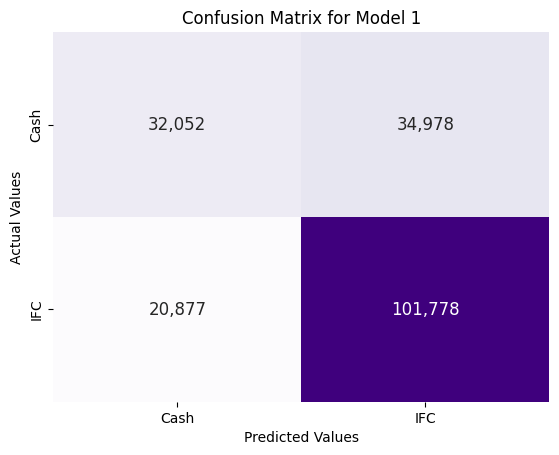

In [38]:
# Set the threshold for the confusion matrix to the optimal threshold (without this step, ot would be set to a default of 0.5)
y_pred_2 = (logreg_2.predict_proba(X_test_2)[:, 1] > optimal_threshold_2).astype('float')

# Generate the confusion matrix
cm_2 = confusion_matrix(y_test_2, y_pred_2)

# Define custom colors and layout
ax_2 = plt.subplot()
sns.heatmap(cm_2, annot=True, annot_kws={"size": 12}, ax=ax_2, cmap="Purples", cbar=False, fmt=',.0f')

# Set labels and title
ax_2.set_xlabel("Predicted Values")
ax_2.set_ylabel("Actual Values")
ax_2.set_title("Confusion Matrix for Model 1")

# Set tick labels for x and y axes
ax_2.xaxis.set_ticklabels(["Cash", "IFC"])
ax_2.yaxis.set_ticklabels(["Cash", "IFC"])

# Show the plot
plt.show()

In [39]:
Accuracy_2 = metrics.accuracy_score(y_test_2, y_pred_2)
Precision_2 = metrics.precision_score(y_test_2, y_pred_2)
Recall_2 = metrics.recall_score(y_test_2, y_pred_2)
Specificity_2 = metrics.recall_score(y_test_2, y_pred_2, pos_label=0)
F1_score_2 = metrics.f1_score(y_test_2, y_pred_2)

print("Accuracy:", Accuracy_2)
print("Precision:", Precision_2)
print("Recall:", Recall_2)
print("Specificity:", Specificity_2)
print("F1 score:", F1_score_2)

Accuracy: 0.7055381290033477
Precision: 0.7442306004855362
Recall: 0.8297908768497004
Specificity: 0.4781739519618081
F1 score: 0.7846853063285674


### Comparison of the models

With the two potential models built, their accuracy metrics were compared.

In [40]:
# Create dataframe from the results of the 2 models
data = {'Accuracy': [Accuracy_1, Accuracy_2, (Accuracy_1-Accuracy_2)], 'Precision': [Precision_1, Precision_2, (Precision_1-Precision_2)], 'Recall': [Recall_1, Recall_2, (Recall_1-Recall_2)], 'Specificity': [Specificity_1, Specificity_2, (Specificity_1-Specificity_2)], 'F1 score': [F1_score_1, F1_score_2, (F1_score_1-F1_score_2)]}
model_data = pd.DataFrame(data=data)
model_data.index = ['Model 1', 'Model 2', 'Difference']

# Print the dataframe
print(model_data)

            Accuracy  Precision    Recall  Specificity  F1 score
Model 1     0.727343   0.777954  0.809343     0.577294  0.793338
Model 2     0.705538   0.744231  0.829791     0.478174  0.784685
Difference  0.021805   0.033723 -0.020448     0.099120  0.008653


Model 1 scores more favourably than model 2 across all metrics, except for recall and specificity. Since recall is not a priority in this particular use case, model 1 was selected as the chosen model. However, it was noted that specificity is a potential concern for this model going forward.